In [1]:
import sleap
import sys
import cmath
import json
import os

sys.path.append('..')
from python.polygon_based_correction import *
from eval.eval import *
from python.dataset_conversion import *

sleap.versions()
sleap.system_summary()

SLEAP: 1.4.1
TensorFlow: 2.7.0
Numpy: 1.21.5
Python: 3.7.12
OS: Linux-6.8.0-51-generic-x86_64-with-debian-trixie-sid
GPUs: 2/2 available
  Device: /physical_device:GPU:0
         Available: True
       Initialized: False
     Memory growth: None
  Device: /physical_device:GPU:1
         Available: True
       Initialized: False
     Memory growth: None


training data -> SLEAP -> SLEAP output -> manual correction -> autoencoder -> final output

manual correction steps (instead of using the tracking function from SLEAP):
1. identify mispredicted points (points predicted at where there isn't a tentacle): prediction score + displacement 
2. assign identity to the rest of the points using optical flow 
3. interpolate missing points using average displacement/optical flow from its two neighbors
4. run polygon-based correction on all points to ensure maximal global alignment with the previous frame

In [19]:
training_json_path = '/home/mingxiao/Desktop/jellyfish/label/multifish/models/250221_022817.centroid.n=4149/training_config.json'
# training_json_path = '/home/mingxiao/Desktop/jellyfish/label/models/250214_122024.single_instance.n=1653/training_config.json'
training_config = json.load(open(training_json_path))

In [20]:
val_indices = np.array(training_config['data']['labels']['validation_inds'])
train_indices = np.array(training_config['data']['labels']['training_inds'])
print(val_indices.shape)
print(train_indices.shape)

(415,)
(3734,)


In [2]:
single_animal_dataset_path = '/home/mingxiao/Desktop/jellyfish/label/animal_1_labels.v002.slp'
single_animal_dataset = sleap.load_file(single_animal_dataset_path)
print(single_animal_dataset)
multi_animal_dataset = single2multi(single_animal_dataset)
print(multi_animal_dataset)

Labels(labeled_frames=8089, videos=1, skeletons=1, tracks=0)
Tentacle count: 17
Average mouth location: [86.18999969 79.86647831]
Labels(labeled_frames=1653, videos=1, skeletons=1, tracks=17)


In [4]:
single_animal_dataset.skeleton

Skeleton(name='Skeleton-1', description='None', nodes=['Mouth', 'TB1', 'TB2', 'TB3', 'TB4', 'TB5', 'TB6', 'TB7', 'TB8', 'TB9', 'TB10', 'TB11', 'TB12', 'TB13', 'TB14', 'TB15', 'TB16', 'TB17'], edges=[('Mouth', 'TB1'), ('Mouth', 'TB2'), ('Mouth', 'TB3'), ('Mouth', 'TB4'), ('Mouth', 'TB5'), ('Mouth', 'TB6'), ('Mouth', 'TB7'), ('Mouth', 'TB8'), ('Mouth', 'TB9'), ('Mouth', 'TB10'), ('Mouth', 'TB11'), ('Mouth', 'TB12'), ('Mouth', 'TB13'), ('Mouth', 'TB14'), ('Mouth', 'TB15'), ('Mouth', 'TB16'), ('Mouth', 'TB17')], symmetries=[])

In [3]:
src_multi_animal_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/manual_5min_c0.slp'
src_multi_animal_dataset = sleap.load_file(src_multi_animal_dataset_path)
print(src_multi_animal_dataset)
src_single_animal_dataset = multi2single(src_multi_animal_dataset)
print(src_single_animal_dataset)

Labels(labeled_frames=9000, videos=1, skeletons=1, tracks=17)
Tentacle count: 17
Labels(labeled_frames=5202, videos=1, skeletons=1, tracks=0)


In [5]:
src_single_animal_dataset.skeleton

Skeleton(name='jellyfish', description='None', nodes=['Mouth', 'TB1', 'TB2', 'TB3', 'TB4', 'TB5', 'TB6', 'TB7', 'TB8', 'TB9', 'TB10', 'TB11', 'TB12', 'TB13', 'TB14', 'TB15', 'TB16', 'TB17'], edges=[('Mouth', 'TB1'), ('Mouth', 'TB2'), ('Mouth', 'TB3'), ('Mouth', 'TB4'), ('Mouth', 'TB5'), ('Mouth', 'TB6'), ('Mouth', 'TB7'), ('Mouth', 'TB8'), ('Mouth', 'TB9'), ('Mouth', 'TB10'), ('Mouth', 'TB11'), ('Mouth', 'TB12'), ('Mouth', 'TB13'), ('Mouth', 'TB14'), ('Mouth', 'TB15'), ('Mouth', 'TB16'), ('Mouth', 'TB17')], symmetries=[])

In [9]:
multi_v11_dataset_path = '/home/mingxiao/Desktop/jellyfish/label/multifish/multifish_animal_1_v11.slp'
multi_v11_dataset = sleap.load_file(multi_v11_dataset_path)
print(multi_v11_dataset)

Labels(labeled_frames=4149, videos=1, skeletons=1, tracks=17)


In [18]:
single_v10_dataset_path = '/home/mingxiao/Desktop/jellyfish/label/animal_1_labels_v11.slp'
single_v10_dataset = multi2single(multi_v11_dataset, save_path=single_v10_dataset_path)
print(single_v10_dataset)

Tentacle count: 17
Labels(labeled_frames=4144, videos=1, skeletons=1, tracks=0)


(9000, 17, 2)
total_range_length: 4264


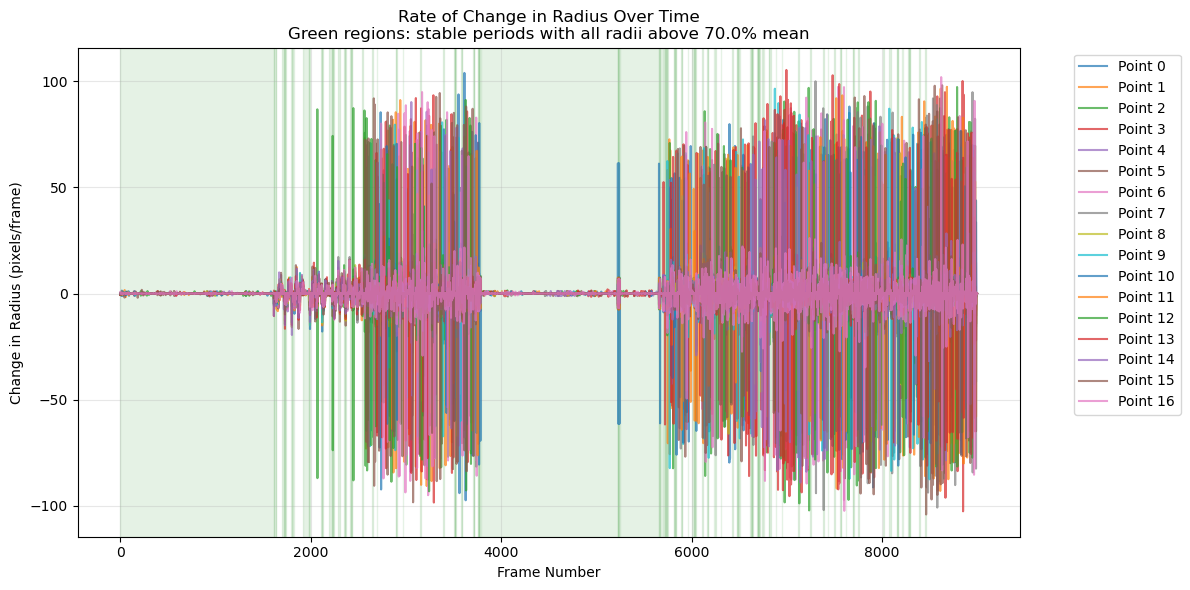

100%|██████████| 9000/9000 [00:03<00:00, 2371.23it/s]


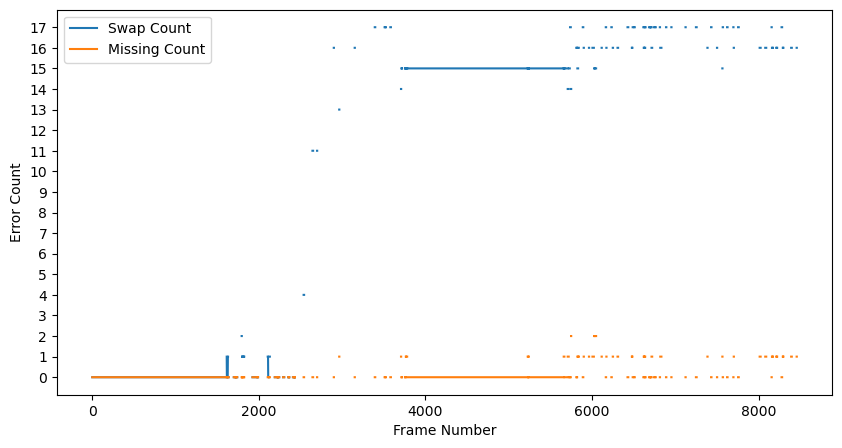

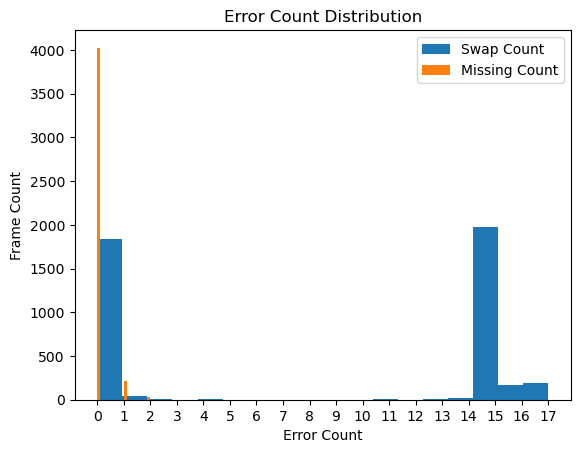

In [17]:
tracked_pts_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/manual_5min_c0_tracked_points.npy'
tracked_points = np.load(tracked_pts_path)
print(tracked_points.shape)
swap_cnt_lst, missing_cnt_lst,filtered_ranges = eval_dataset_from_points(tracked_points)

## multi-animal model

### 4k, uncorrected

(3240000, 18, 2)
total_range_length: 1460367


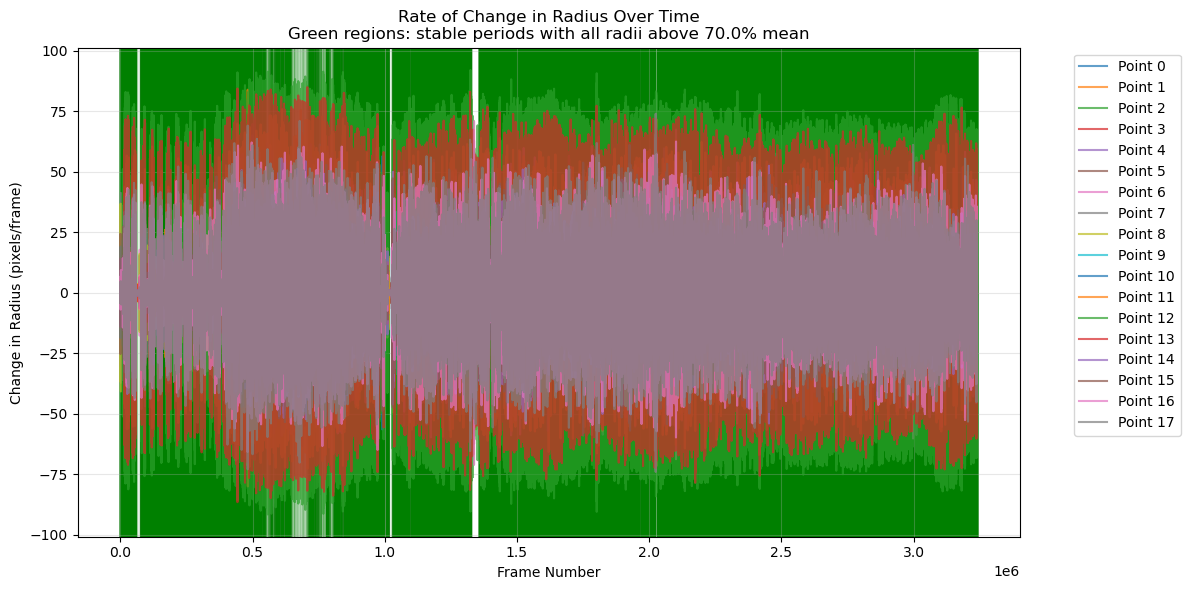

100%|██████████| 3240000/3240000 [24:08<00:00, 2236.83it/s] 
/home/mingxiao/micromamba/envs/sleap/lib/python3.7/site-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


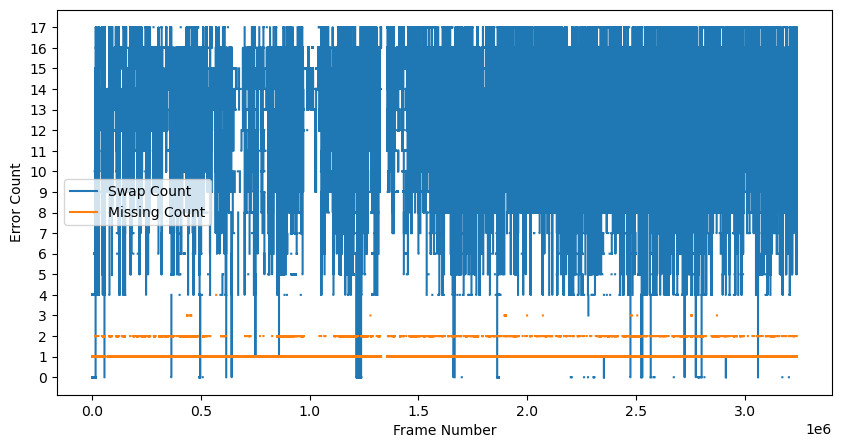

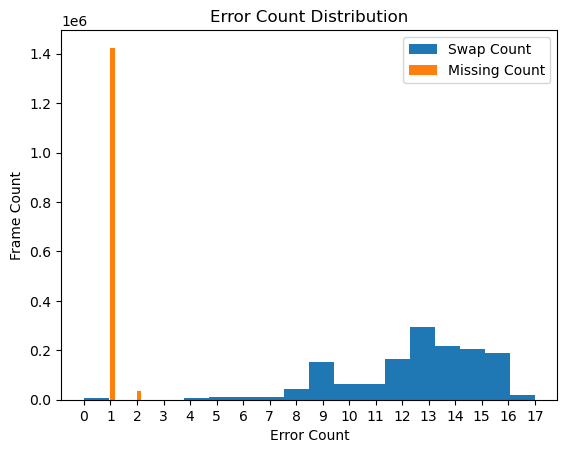

In [18]:
multi_4k_points_path = '/home/mingxiao/Desktop/jellyfish/label/multifish/predictions/multifish_animal_1_v10_tracked_points.npy'
multi_4k_points = np.load(multi_4k_points_path)
print(multi_4k_points.shape)
swap_cnt_lst, missing_cnt_lst,filtered_ranges = eval_dataset_from_points(multi_4k_points)

### test dataset only

In [2]:
# dataset_path = "/home/mingxiao/Desktop/jellyfish/label/multifish/multifish_animal_1_v10.slp"
dataset_path = '/home/mingxiao/Desktop/jellyfish/label/multifish/predictions/multifish_animal_1_v10.slp.250221_051111.predictions.slp'
dataset = sleap.load_file(dataset_path)
print(dataset)

Labels(labeled_frames=3240000, videos=1, skeletons=1, tracks=0)


In [29]:
all_lbfs = dataset.labeled_frames
# print(all_lbfs.shape)
print(len(all_lbfs))
test_lbfs = [all_lbfs[i] for i in val_indices]
test_lbf_indices = [lbf.frame_idx for lbf in test_lbfs]
# print(test_lbfs.shape)
print(len(test_lbfs))

4149
415


In [48]:
# from typing import List

# def get_all_untracked_points_from_lbfs(lbfs: List[sleap.instance.LabeledFrame],
#                                        reorder: bool = True, 
#                                        interpolate: bool = True,
#                                        min_score: int = 0, 
#                                        start_idx: int = 0, 
#                                        tb_cnt: int = 17) -> np.ndarray:
#     """
#     Get all untracked points from a list of labeled frames.
#     """
#     frame_cnt = len(lbfs)
#     instance_cnt = len(lbfs[0].instances)
#     all_untracked_points = np.zeros((frame_cnt, instance_cnt, 2))
#     print(f'all_untracked_points shape: {all_untracked_points.shape}')
#     missing_point_cnt = 0

#     # populate all_tracked_coords with known coordinates
#     for frame_idx, lf in tqdm(enumerate(lbfs)):
#         pred_insts = [instance for instance in lf.instances \
#                         if isinstance(instance, sleap.instance.Instance)]
#         if len(pred_insts) > tb_cnt:
#             pred_inst_scores = [instance.score for instance in pred_insts]
#             sorted_args = np.argsort(pred_inst_scores)[::-1][:tb_cnt]
#             pred_insts = [inst for i, inst in enumerate(pred_insts) if i in sorted_args]
#         for inst_idx, instance in enumerate(pred_insts):
#             pt_coord = instance.points_array[0]
#             if pt_coord.sum() == 0:
#                 missing_point_cnt += 1
#             all_untracked_points[frame_idx - start_idx, inst_idx] = pt_coord

#     first_non_missing_frame_idx = start_idx
#     # interpolate missing coordinates
#     if interpolate:
#         first_non_missing_frame_idx = None
#         for frame_idx in range(frame_cnt):
#             curr_frame_missing_point_cnt = 0
#             for inst_idx in range(instance_cnt):
#                 if all_untracked_points[frame_idx, inst_idx].sum() == 0:
#                     curr_frame_missing_point_cnt += 1
#                     prev_frame_idx = get_prev_frame_idx(all_untracked_points, frame_idx, inst_idx)
#                     next_frame_idx = get_next_frame_idx(all_untracked_points, frame_idx, inst_idx)
#                     all_untracked_points[frame_idx, inst_idx] = (all_untracked_points[prev_frame_idx, inst_idx] + all_untracked_points[next_frame_idx, inst_idx]) / 2
#             if first_non_missing_frame_idx is None and curr_frame_missing_point_cnt == 0:
#                 first_non_missing_frame_idx = frame_idx
#                 print(f"First non missing frame idx: {first_non_missing_frame_idx}")
#     print(f"Missing point count: {missing_point_cnt}")
    
#     if reorder: 
#         reorder_idx = poly_4(all_untracked_points[first_non_missing_frame_idx])
#         print(f"reorder_idx.shape: {np.array(reorder_idx).shape}")
#         all_untracked_points = all_untracked_points[:, reorder_idx, :]
    
#     return all_untracked_points

In [3]:
test_untracked_points = get_all_untracked_points_from_lbfs(test_lbfs, interpolate=False, reorder=False, use_labeled_only=False)
print(test_untracked_points.shape)

NameError: name 'test_lbfs' is not defined

In [53]:
def eval_discrete_points(tracked_points, frame_indices,
                         binarize=True, 
                         method='nn',
                         count_missing=True, 
                         polygon_constructor=poly_4):
    
    swap_cnt_lst = []
    missing_cnt_lst = []
    for i in tqdm(range(len(tracked_points))):
        swap_cnt, missing_cnt = get_err_count(tracked_points[i], 
                                                count_missing=count_missing, method=method, binarize=binarize, polygon_constructor=polygon_constructor)
        swap_cnt_lst.append(swap_cnt)
        missing_cnt_lst.append(missing_cnt)

    plt.figure(figsize=(10, 5))
    plt.scatter(frame_indices, swap_cnt_lst, s=10, label='Swap Count')
    plt.scatter(frame_indices, missing_cnt_lst, s=10, label='Missing Count')
    plt.legend()
    plt.xlabel('Frame Number')
    plt.ylabel('Error Count')
    plt.yticks(range(18))
    plt.show()
    
    plt.hist(swap_cnt_lst, label='Swap Count', bins=18)
    plt.hist(missing_cnt_lst, label='Missing Count', bins=18)
    plt.legend()
    plt.xlabel('Error Count')
    plt.ylabel('Frame Count')
    plt.xticks(range(18))
    plt.title('Error Count Distribution')
    plt.show()
    
    return swap_cnt_lst, missing_cnt_lst,filtered_ranges


100%|██████████| 415/415 [00:44<00:00,  9.33it/s]


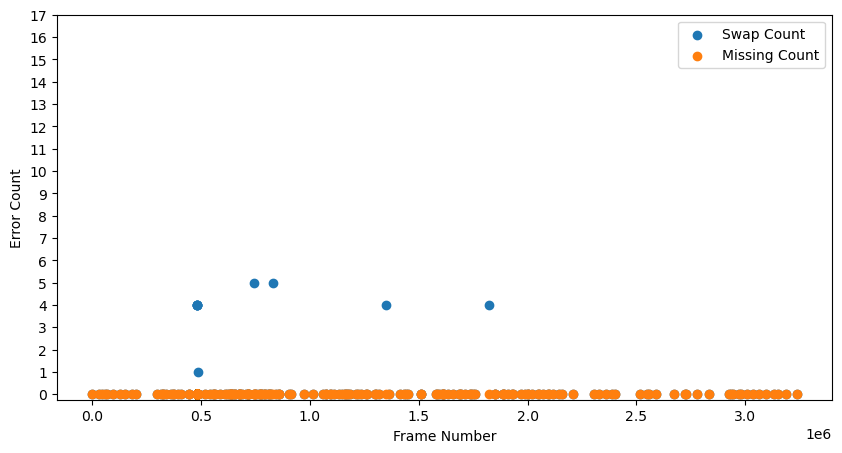

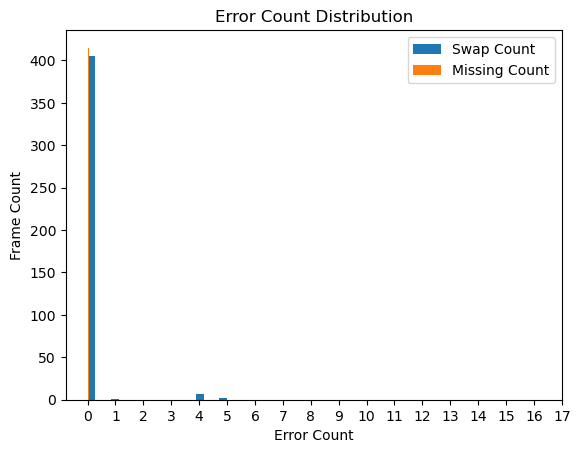

In [54]:
swap_cnt_lst, missing_cnt_lst,filtered_ranges = eval_discrete_points(test_untracked_points, test_lbf_indices, method='polygon', count_missing=True)